# 159/160 vs Frontier | v20 WEED-Slip Recovery

**Current-route mirror control + identity-free recovery from visible WEED slips**

The title's **159/160** is a fresh closed-loop benchmark against the exact public
Frontier agent: 80 new random seeds, each played from both seats. It is **not an
official Public-LB score**. Frozen v20 scored 151/160 in the same paired games;
the bounded recovery converted eight losses to wins and no wins to losses.

This is an update to the existing medal-winning v20 Notebook, not a new page.
The mirror controller, route and 40/40 anti-copy result remain intact. The new
question is narrower: when a strong open-loop route silently tries to plant or
build on a visible WEED, can one actor recover without disturbing market orders
or the other workers?

```text
v19 decay -> train-only current medoid -> mirror-label audit
          -> 7-feature logistic model -> step-48 route choice
          -> state-ranked SELL front-running
          -> visible-WEED transaction -> exact public artifact
```


## 1. Public research lineage and why this stays v20

This version preserves the same public URL, votes and research lineage:

| Work | Contribution carried into v20 |
|---|---|
| [Kaito v18 — 40/53 Top-10 Future Holdout](https://www.kaggle.com/code/kaitofukami/40-53-top-10-future-holdout-v18-closed-loop?scriptVersionId=340030138) | Both-seat outcome validation and complete-route controls |
| [Kaito v19 — 41/49 Replication to Control](https://www.kaggle.com/code/kaitofukami/41-49-future-unseen-v19-replication-to-control?scriptVersionId=340133955) | Replication audit, train-only medoids and late closed-loop inventory control |
| [Rayk Kretzschmar — Findings from Zero to Top Meta](https://www.kaggle.com/code/raykkretzschmar/kaggriculture-findings-from-zero-to-top-meta) | Independent cross-play and evidence that common routes need explicit controls |
| [Kun Zhang — C20 Exact Replication Control](https://www.kaggle.com/code/beicicc/kaggriculture-c20-exact-replication-control) | Exact-attribution and terminal-safety discipline |
| [prvsiyan — Kaggriculture Frontier: The Moon Counts Melons](https://www.kaggle.com/code/prvsiyan/kaggriculture-frontier-the-moon-counts-melons) | Cause-specific public-WEED repair and bounded trace catch-up |

On 2026-08-05, v19 showed **185 views,
16 votes and 14 copies**. All copies
were private, so their authors and code were not observable. v20 therefore
detects convergence from public replay behavior—not user identity, notebook
ownership or a team-name lookup.

Credit boundary: this update does **not** copy prvsiyan's Subin route, literal
market tapes or exact shop profiles. It independently generalizes the published
PLANT recovery idea into one identity-free `PLANT`/`BUILD_PASTURE` transaction
on the frozen v20 route. The linked source is the direct inspiration and should
be cited by downstream forks using this mechanism.


## 2. The old edge really decayed

The fresh snapshot contains **183 unique episodes**: 122 older episodes for
route/model fitting and 61 later episodes held out. On one later case per
current Top-20 team and seat, frozen v19 won only **10/38**. A train-only medoid
of the current `sash` lineage won **34/38**.

The route refresh is the largest effect in v20. The adaptive layer is evaluated
on top of that stronger control rather than receiving credit for the refresh.


,policy,wins,games,win_rate
0,frozen v19,10,38,0.263158
1,current train-only medoid,34,38,0.894737


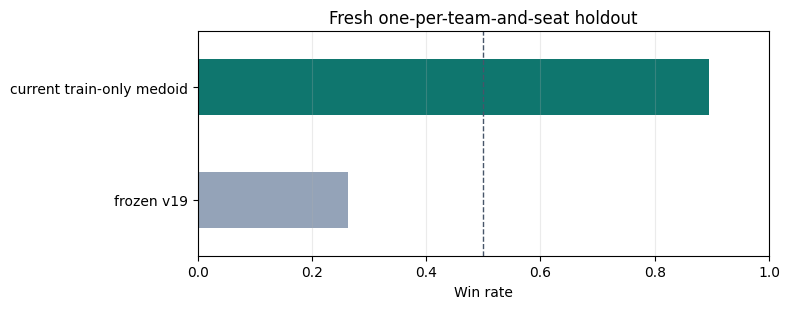

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

decay = pd.DataFrame([
    ["frozen v19", 10, 38],
    ["current train-only medoid", 34, 38],
], columns=["policy", "wins", "games"])
decay["win_rate"] = decay.wins / decay.games
display(decay)

ax = decay.plot.barh(
    x="policy", y="win_rate", legend=False, figsize=(8, 3.2), color=["#94a3b8", "#0f766e"]
)
ax.axvline(0.5, color="#475569", linestyle="--", linewidth=1)
ax.set(xlabel="Win rate", ylabel="", xlim=(0, 1), title="Fresh one-per-team-and-seat holdout")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()

## 3. Testing the mirror hypothesis without lookahead

At turn `t`, both policies choose simultaneously. We cannot read the opponent's
current action. The deployable prediction is therefore:

```text
public farms at t + public money at t + current step t
                         -> P(our market intent at t == opponent intent at t)
```

Offline replay actions supply labels only. They never enter runtime features.
A deliberately strict public-state gate—24 near-equal-board turns, board
distance at most 2, money gap at most 5—activated in 57/61 later games. Within
that gate, later replay actions had:

| Equality target | Holdout rate |
|---|---:|
| Complete action | **90.53%** |
| Board action | **93.92%** |
| Exact market action | **96.51%** |
| Ordered market intent | **99.11%** |
| Non-empty market intent | **98.44%** |

This supports the hypothesis as a conditional statement. Similar farms do not
prove identical private inventories, so the controller uses only our own legal
SELL quantities and treats the prediction as a route signal—not an oracle.


## 4. Convergence is visible across author names

Hashing full, board-only and market-only trajectories exposes several shared
behavioral lineages in the later holdout:

| Component | Largest cross-team cluster |
|---|---|
| Full action | Le Viet, Winter Lamb |
| Board path | Le Viet, Savko, Winter Lamb, somewhere after |
| Market path | Lucien de Rubempre, somewhere after |
| Market path | Le Viet, Winter Lamb |

The useful unit is behavior, not attribution. This is also why a hardcoded
"counter team X" branch would be both brittle and scientifically weaker.


## 5. A small learned model, not a hand-written mirror threshold

The mirror classifier is logistic regression fit only on 63,028 non-empty
market turns from the 122 older episodes. Its seven public features are board
distance, exact-board status, money gap, near-equal-money status, a 96-turn
board-similarity streak, normalized time and late-game status.

The operating threshold `0.806519` was selected for 95% train
precision. It transferred to the untouched 61-episode split with **94.90%
precision** at **32.52% coverage** (10,246 selected turns out of 31,510).


,standardized feature,coefficient
0,log1p_board_distance,-0.945128
1,exact_board,-0.468027
2,log1p_money_gap,-1.461597
3,near_equal_money,0.599422
4,near_board_streak_96,-0.154561
5,step_fraction,0.442220
6,late_phase,-0.025623


,split,precision,coverage,rows
0,train,0.950012,0.317399,63028
1,later holdout,0.948956,0.325167,31510


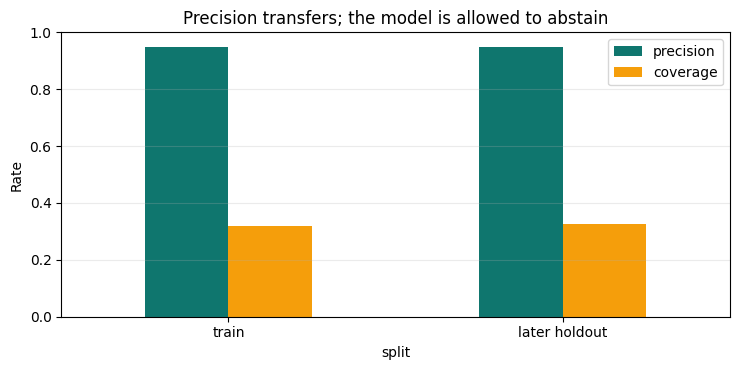

In [2]:
coefficients = pd.DataFrame([
    ["log1p_board_distance", -0.945128],
    ["exact_board", -0.468027],
    ["log1p_money_gap", -1.461597],
    ["near_equal_money", 0.599422],
    ["near_board_streak_96", -0.154561],
    ["step_fraction", 0.442220],
    ["late_phase", -0.025623],
], columns=["standardized feature", "coefficient"])
display(coefficients)

quality = pd.DataFrame([
    ["train", 0.950012496875781, 0.3173986164879101, 63028],
    ["later holdout", 0.9489556900253757, 0.3251666137734053, 31510],
], columns=["split", "precision", "coverage", "rows"])
display(quality)

ax = quality.set_index("split")[["precision", "coverage"]].plot.bar(
    rot=0, figsize=(7.5, 3.8), color=["#0f766e", "#f59e0b"]
)
ax.set(ylim=(0, 1), ylabel="Rate", title="Precision transfers; the model is allowed to abstain")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()

## 6. Current route provenance

The base is the train-only medoid of eight `sash` trajectories: the complete
trajectory minimizing summed board+market turn Hamming distance to the other
older trajectories.

| Field | Value |
|---|---|
| Public episode | `90049120` |
| Player | `0` |
| Train trajectories | `8` |
| Medoid sum distance | `5239` |
| Complete action SHA-256 | `c234e990fd63a168535b55de1f11289fa2bbc563b390390b49d0d65169cedb18` |

The route contributes `farmer`, all `hands`, BUY/HIRE and SELL timing for the
complete game. v20 does not reduce the game to a late SELL-only script.


## 7. Two-route closed-loop control

The runtime observes public state until step 48, then commits to one of two
execution regimes:

```text
                         logistic P(mirror)
                                |
                +---------------+---------------+
                |                               |
          mirror regime                    open regime
    front-run while learned latch       front-run continuously
    remains valid; release after        after the decision step
    8 divergent board turns
                +---------------+---------------+
                                |
             rank scheduled SELLs by current public state
    opponent exposure × glut sensitivity × price × log(1 + own quantity)
                                |
       step 718: replace market with every legal projected own SELL
```

The environment processes market orders in sequence, so moving a scheduled
SELL earlier can capture the pre-glut price before a later same-product order.
Quantity is capped by our own projected shed. BUY/HIRE timing and all unit
actions still come from the complete current route.

The regime decision is learned; the market best response is an interpretable,
legal state controller. Runtime uses public opponent farms, public prices,
public money and our private inventory only.


In [3]:
from math import log1p

def sell_priority(opponent_exposure, glut_weight, current_price, own_quantity):
    return (
        (1.0 + opponent_exposure)
        * glut_weight
        * max(1.0, current_price)
        * log1p(max(0, own_quantity))
    )

print("The deployed controller ranks legal scheduled SELLs with this score.")

The deployed controller ranks legal scheduled SELLs with this score.


## 8. Outcome ablation

| Policy on all current Top-20 later cases | Wins | Mean margin |
|---|---:|---:|
| Current medoid control | 98/108 | 2,681 |
| Learned mirror latch only | 99/108 | 6,340 |
| Always front-run | 102/108 | 9,245 |
| **v20 hybrid-48** | **102/108** | **7,885** |

The learned-only branch adds one win over the medoid; front-running adds four.
The hybrid matches the best win count while retaining an explicit mirror/open
structure for future adaptation. Seat 0 is **53/56** and seat 1 is **49/52**.


,policy,wins,games,win_rate
0,current medoid,98,108,0.907407
1,learned latch,99,108,0.916667
2,always front-run,102,108,0.944444
3,v20 hybrid-48,102,108,0.944444


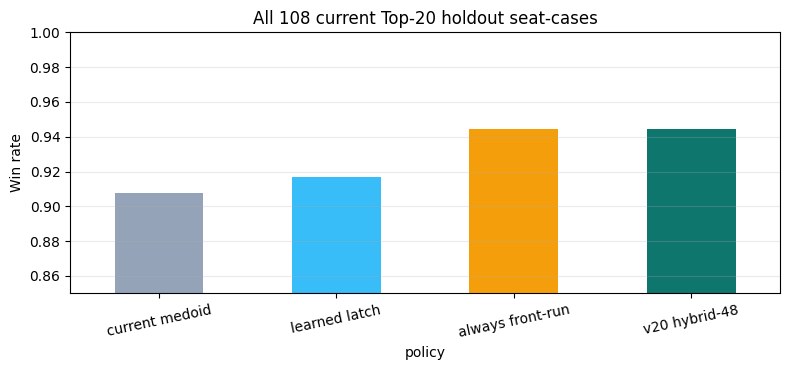

In [4]:
ablation = pd.DataFrame([
    ["current medoid", 98, 108],
    ["learned latch", 99, 108],
    ["always front-run", 102, 108],
    ["v20 hybrid-48", 102, 108],
], columns=["policy", "wins", "games"])
ablation["win_rate"] = ablation.wins / ablation.games
display(ablation)

ax = ablation.plot.bar(
    x="policy", y="win_rate", legend=False, rot=12, figsize=(8, 3.8),
    color=["#94a3b8", "#38bdf8", "#f59e0b", "#0f766e"]
)
ax.set(ylabel="Win rate", ylim=(0.85, 1.0), title="All 108 current Top-20 holdout seat-cases")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()

## 9. Anti-copy benchmark: development, then untouched seeds

The paired benchmark pits each candidate against an exact frozen copy of the
base schedule. It runs both seat assignments for every seed.

| Split and policy | Wins | Losses | Ties | Mean difference |
|---|---:|---:|---:|---:|
| Development: exact base vs exact base | 12 | 12 | 16 | 0 |
| Development: always front-run | 39 | 1 | 0 | 97,578 |
| Development: learned latch | 40 | 0 | 0 | 91,272 |
| **Untouched: v20 hybrid-48** | **40** | **0** | **0** | **64,095** |

Untouched seed range starts at `30260805`. v20 is **20/20 from seat 0** and
**20/20 from seat 1**; the minimum winning difference is
**14,653**. This is the title metric.


## 10. Broader generalization

| Evaluation population | Control | v20 hybrid-48 |
|---|---:|---:|
| Current Top-20, all later seat-cases | 98/108 | **102/108** |
| Teams outside current Top-20, later holdout | 10/14 | **13/14** |
| Exact frozen base, future seeds and both seats | 11 wins / 11 losses / 18 ties | **40/40 wins** |

The non-Top-20 slice is small, so 13/14 is supporting evidence rather than a
population estimate. It nevertheless checks that the front-running controller
does not only memorize the Top-20 names.


## 11. Failure atlas: six losses were visible route slips

The 102/108 aggregate hid a common causal failure. In every lost later replay,
at least one scheduled `PLANT` or `BUILD_PASTURE` reached a tile that was visibly
`WEED` at decision time. The action was legal in shape but ineffective on the
board; the actor then continued an open-loop schedule one turn out of phase.

The public Frontier agent was a useful falsification control. On the same 108
games it won all six v20 losses, but won only 85/108 overall and turned 23 safe
v20 wins into losses. Its full route is therefore complementary, not a safe
replacement. The portable insight is the cause-specific recovery transaction.

```text
intended PLANT/BUILD on visible WEED
                 |
              DIG now
                 |
       retry the exact intention at t+1
                 |
 replay only that actor's prior route action for <= 8 turns
                 |
      resume v20; market and other actors never changed
```

No opponent identity, source ownership, seed, episode ID or hidden state enters
this decision.


## 12. Recovery ablation and fresh closed-loop falsification

| Panel | Frozen v20 | DIG + retry only | DIG + retry + 8-step catch-up |
|---|---:|---:|---:|
| Earlier Top-20, all 205 cases | 188/205 | 201/205 | **202/205** |
| Later Top-20, all 108 cases | 102/108 | 105/108 | **108/108** |
| Later teams outside Top-20 | 13/14 | — | **13/14** |
| Fresh exact Frontier, 80 seeds x 2 seats | 151/160 | — | **159/160** |

On the 205-case earlier panel, catch-up converts **14 losses to
wins and 0 wins to losses**. On the 14-case non-Top slice there
are no win/loss flips; mean margin changes from
**3,882** to
**4,277**.

The 108/108 row is deliberately labelled exploratory: its six failures were
inspected before this repair was built, so it is not an untouched holdout. The
title uses the separate closed-loop Frontier test. Across those 160 paired
fresh games the repair converts **8 losses to wins and
0 wins to losses**. One game remains a loss at -945.

The result supports a narrow claim: public-state recovery removes a recurring
fixed-route failure and transfers against the exact cited adaptive agent. It is
not evidence that eight steps is universally optimal.


,panel,frozen v20,slip recovery,games
0,Earlier Top-20,188,202,205
1,Later Top-20 (exploratory),102,108,108
2,Fresh exact Frontier,151,159,160


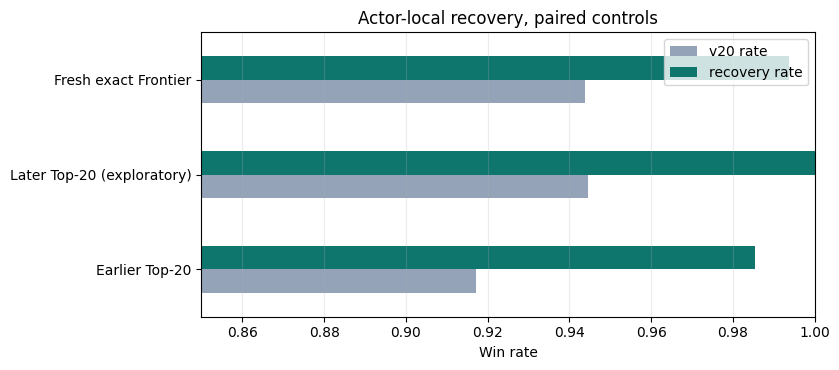

In [5]:
recovery = pd.DataFrame([
    ["Earlier Top-20", 188, 202, 205],
    ["Later Top-20 (exploratory)", 102, 108, 108],
    ["Fresh exact Frontier", 151, 159, 160],
], columns=["panel", "frozen v20", "slip recovery", "games"])
recovery["v20 rate"] = recovery["frozen v20"] / recovery.games
recovery["recovery rate"] = recovery["slip recovery"] / recovery.games
display(recovery[["panel", "frozen v20", "slip recovery", "games"]])

ax = recovery.set_index("panel")[["v20 rate", "recovery rate"]].plot.barh(
    figsize=(8.5, 3.8), color=["#94a3b8", "#0f766e"]
)
ax.set(xlabel="Win rate", ylabel="", xlim=(0.85, 1.0), title="Actor-local recovery, paired controls")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()

## 13. What v20 does *not* claim

1. Replay opponents are open-loop and cannot react to our counterfactual move.
2. The 40/40 opponent is the exact frozen base schedule, not an adaptive copy
   of the entire v20 policy. Two identical deterministic v20 agents cannot be
   guaranteed a systematic edge over each other.
3. Current actions are simultaneous. Runtime predicts equality from state; it
   never observes the opponent's current action.
4. Similar public farms do not reveal private opponent inventory.
5. `40/40`, `102/108` and `13/14` are local reproducible studies, not official
   leaderboard scores or medal guarantees.
6. A future population shift requires a new chronological snapshot. Refitting
   on these holdouts would invalidate their role.
7. `108/108` is post-hoc because the six failures were inspected first.
8. `159/160` is fresh and both-seat, but it covers one public opponent family.
9. Eight replay steps are a bounded recovery horizon, not a learned optimum.

The falsifiable next test is a future snapshot in which adaptive v20 forks are
the opponents, with the current artifact frozen before replay collection.


## 14. Public source contract

- Exact `main.py` bytes: **26,894**
- Exact SHA-256: `231cf97fcadb1481e2936395f9a6ac8592b8740903c8f93ec9f88b704e20ac24`
- Embedded complete schedule actions: **719**
- Mirror model: **7 features**, train-only fit
- Slip recovery: visible WEED only, actor-local, maximum **8** catch-up turns
- Test suite at publication: **54 passed**
- Dependencies: Python standard library only
- Runtime exclusions: no network, identity lookup, opponent private state or online fitting

Useful entry points for humans and code-reading agents:

```text
_public_farm_distance(left, right)
_mirror_probability(distance, money_gap, board_streak, step)
_ranked_sells(obs, action, requested)
_front_run_market(obs, action)
_terminal_market(obs, action)
_weed_repair_action(obs, action, step)
_hybrid_action(obs, action, step)
agent(obs)
```

The final cell reconstructs this exact source, creates the submission archive,
and runs the agent against an exact base copy from both seats.


## 15. Build and verify the exact Notebook-linked submission

This cell writes `/kaggle/working/main.py` and `submission.tar.gz`. The same
`main.py` is the file linked to this Notebook version for the competition
submission.


In [6]:
import base64
import copy
import hashlib
import importlib.util
import tarfile
import zlib
from pathlib import Path

WORK = Path("/kaggle/working")
if not WORK.exists():
    WORK = Path.cwd()
MAIN_PATH = WORK / "main.py"
ARCHIVE_PATH = WORK / "submission.tar.gz"

_AGENT_B85_PARTS = [
    'c-qaqd6%L{mpJ@?eF{yN0ZnVzL}>Q~R}}ZHPKl_f2m%7GsGt1>71PYBuI_ne&hNZ=x-',
    '%h&xO?1t<3>Qey}ebq#X=LNTgljJylaO*f4SCzrYV|hs>p_>NG?^{>MnIVk%VbTH#mcL>5`zjG=8e=c<uQ8+qWjK^PDzax+Fp7xd',
    'rdy<e6*ENxCo>xQS$e<s@Oo8G<6aI19^6nQqs-',
    'Z16LeAiInu{{U~J|5j5BexfMicbBVeJ<+zZA*^}VR_7fmEYR9oe|PTIip(G1UCLf|shY5}2^8d=1zypP@84`vYz)(_rde&SHK&QZ',
    ';ZkJjXkjQBt|h0tWW^=(#$M4x7dM^qy6&?0H+XIxk~s^vWRbH~Ek<pECdyWxS(NuED(5mZPS&~UjWa>F@an3dSq~>ii<X@(969;F',
    'o@Bq-!>fwbHEY2z^lw#OQe^$j<*<B{n_xj#dFz*KNJrO#mwC;S-pK+ww~4Yq%r)i2%eJswnzA+c@890u-',
    'oAYk)~cczt_i2}IOg0<74_&`uXIIruGgHgbgoa5F!}cF8=KCyOH8fhir;#EmlSTM1NOu3GfUTNRkH*G+`)gJ5MjG<#slA6*3bR-',
    'e@#RGb-',
    '&QW7?T*n3TIa3^(ZqMyNzhG83wuikuMAj7b83>VKr)K_C^F0AQHvVbT0xsu2E~Y{aZlhyW;vdU{;5A$z(ic4^jJ><~6tWNR57F?b',
    'DZu_3?oU?M5eZpo(;+17JI937bheJ>Q6@6~LflSXiU+c@CM!2hA3lQatQBwu}0@4xMo_;~vwirk~GU_h7o(y~f)6DIS~cgXqDW9$',
    'SO4qDKf*JU~UG*rk?%6PF*GV>h=@(90&+PRxxm8!j8CW6e~(<IOonOhs{ukM(`}Bn?(GEc-weXdIh+<{)0fSq#F0JuWPqdMPN=KX',
    '1@{2-@?iSzp#;=X|Imj-',
    'w+8R&z&)=D`rEg?i`0hSO?>SA>tA!;GmH_Z^1?vObHA$_qKG)HD4+;Mh#pMZX@RxC;`mHPZm9jW*{%GQsB023qDjad_qS<mRlK3r',
    ';=5YmCgtr$DMu6U%55mNdGy^*NwB{UvnJ;V~`j&z?<?$)1ObbXvq?f$W49R;jr(i{e8ytZCje#*WK<(pN3OBTuy=g9w$5O^4H1DR',
    'GJ7HSH=?0B<^#G(94$UJLcDkWgcuepGs(TDBpSA2eq)*Dg=zQ?=n~MfB)~YM%?^dI`RqhO=aF%T9vxN#Wp!;sGy+E=yp)74u9>G*',
    '0+BW2P&m{kf9&0+^-',
    'FA~|&P8FU`k{8tGY6lk7JJWv%2*>Ly7&pqBXW@MIYcZe^Dz4(#<Ya6;PYW+2Q46yY$Rm^4rC;BpuE~1Npry6d{KtPxmN}1*SQVTc',
    'x#?Z_=q6+YVJS2@T!$SMC8u^QzZKbp=m3!$E6D#k+n733Nkg$B>+daiM>rDFL!g!n3uvKX9fWYBYOjM@kNb_~`1h86rC+;9AVq2^',
    '-?5whVZX?ZEcs&BgsdZon2IOwl#|e>QYkbb8Ce3~roSgjoQm~jrBQui%a<JGZi%M;OnhXA2a6XFEY7bP~Fp_Gsa-',
    '0M&>X2lb5K2zrSVHu*oAa4^)h|0ro0^79#V6TiaORKTYHA&30t}pK)tTX>$Ck*Yx9;g(=hy8i*xxHhj0?y{Ib1}>4nMn0uwORP2&',
    '+!~3D&ISSv|xZL2%BrfeZzD#X%&S7d2zX1gi*>LZ{<&tK%Ilg0m3S5k^F9Qv$njV%VO*nBSZRmttsG)iT{-',
    ')=i7qx{zEnuMbqKwULNj5ibfeIK}4Fs*-AUhpBb|aZe4kH!4-;`+RgkiEfkL(uYK$t0mY>I;MhBL72yjSIcil-',
    '26Pa(tDj~p%Cjp<*e3Ecy!;+J0}x)zu9=80@eC;guq8mcbDjJzG3diiS2S21`x)ZO6>h*qNAQPjfr_yJ*uTGy&4GZ_HpSj0<HPz$',
    'fnJ3v4H?J&T9I)f-%Amn)<OEZ>7`>#`1G+Q%?qni^1-',
    'D8B8BE+4E^dtLp<P<<AMUer@401SY{_8i81|(7x2NJw6uJYDymi=dDXs5q7!C162hMcUH4-%-',
    'ibuQM5HUN|i3iT@T`Z7aj7eTp(?Ti4fUi1Bu-6T<MWa4HOfZzTVli=83!j(7B~pA>5KTRv?3ZZQ@%#E!G#PcXpHXur)WN#-',
    '+AT3KCLEmrCU+-MSu((m4okaFYqODoib54%<m*B!Mz$w3!%<hXWQpk&#wMN3*_oM>{M!N)NT>^x@pyoGXW64McF-',
    '%Xx5rd0b*r1UF0Vr^odb8nvPwA%syEGnydt28YfwV=U|qGW8%;z@HOydN>{E(%zrpSZ@aGh0x2OnT(my43^anwe%@i+vus&PCoJn',
    'QWHzUW!_8F;YQYs1h>b07S>?Sa3j#pdl4Lv;>1&&FPrH`G!Q!k1C|iLs8?qJU!z!WE40zuwIr=K+*U(qWI(H}T@`@O`Ert}^~nm{',
    'nYky$i4l*pmMb>Ub#*#0T0Zx1bNZlpJf8UnzW5v@q)j(Em{*gPwAPI3o>QUkK2BN$+vNcASn3Xg{w}YiflKGuT~9N3c1nh0`HEMn',
    'MDXBRW@F+7mWPvO*X*x2wYrY-Ac)7k#AfCgV&lsAbYhQHG*%i4hYq7@Q6E*c)aMgtGggUID(ebL`N#e>goUcLRK=6LcmcFHN-nZb',
    'ks$E0<>i?8X|Nq<V*pR^P_kYW+|4dbj}HO&JV<-02d6ij&2$@K$xAoWnm03rGx0!y97r=M-',
    'APu*B8wL~!}1Y4m)vF5C#l+HGSl5eH$N95t>nCwt4*nmcm%p9oP+6NqA#sSM}Am{%}Z;~ge=eCQ>_0$Rjp=*CgdL!3h6#nzpQJ?7',
    '?*AjJR34s<Kn5KQqZMkD}%@jp6pJTBcP=Mdhmd3lRINo@>KydwOO7Ty3FV~sJcom8Be&GX%L9pQ&?9aW1no*AE-',
    'v`Nh$LZK}^z?Bz=VSJId%6;xgi}Uc)H&hZMNRkxcv;BYNbnp^CFW3TsPZXOxmiGda$0Hg(SmujAK5_s9<x-',
    'Lx4E9q>v?*uv8=)oVHOOPa#9ZQyMXO=JQ@r|1b?Nl4;|@oKywg0WF^8Xv7VK^PrFz@>iKo;=rq*s`2mm)I5f9lj7G2UIrFFqU<7u',
    '2$F)7Cb?hRJ#YBySU;nO{0~jIf`*yMvZD_kQ^2;fEwqQ3RgBnZT55m^G;=>G`ErAbYjdlhr#Y}0hdFVnD4Jz9baf#BsNlzErE48b',
    'A(M>hZEm#=W<#nR!D?f<8UL_uBPGi7>j7<iqs~m5y3k?m(xJHy{g3byira+Q0>$1_L@0$-OX_&LRE|DxZw+23&DK8md>3jr-q_(k',
    '({`1bf8pVnHg>lXwbh*&Y&~Z-X^^1noc)W_T&aQjM$*mj`nmVJ-c1c6Y%`l^oq@c(R1d-',
    'T*n5%LlJPdPU{0cDFX%XX>stJ55>Zs>>RW0<+_p@k3hC{cI(v;n-<S_e!BI{Duviu_127>j-s$<l~TdeVsq-',
    '9p>ks!j0mM=PTgHcm4Yw%Ks8%5vt?9>l{TjZGogpMfR%GXFzD8&gTQ1^iJgUjKR7DuV6fU)FkIlY?To9nn1{-S#7@QA2iv`-',
    ';2~1|zGu|-',
    'RRWk;=yu7SqaeA0rjy%5dz|iI`4$iZqUpnWjbtMJ$a&L=;4s>+6GMSDI}kWOl~)v#59~U6$72X7otp_kc2o5kS0vA{oR}fz<Y>E+',
    'aeP`uYW>xqWR?t6f1p~!*S##P$trU4tlZp{jb%s2MX$lbiy{T&!{#Iz8sr(@pb#8f0CJM-',
    '1iPd^S{@e6j`vvTq);*3miTO1_c+wAf~#Ovv6|Ng*F?M%n)Pi0QLjJNJf5l^INLpM-',
    '9!#>x(@~cC>+V<J!D1FYAskBmtZZ{=lmx^GkH3pY%(xd<C4{GCE@S;WO|QHK|Z&r(t(ydR<D(95k!3Zyw(Sb;~ZNm!#li@o$8A2K',
    'FosTd{`f74^%bdMB=M!xn=IA$st3G`-u!SD9!<`T`IMX+(6|=z-r45;)PCocP^JajO9XhKuO?{(NaV^^)(-2s-',
    'CkCSRczfUpkf(r_e4n;{8%fMhBDJu;_$K`pkCI{fW7ke8JrW+V#8r201J4<1{)qXneOw8Z{w27@RRALqUBLWOoX-',
    'GUi1pU9GW)z1+@~bssXAsG0GQl2vRWp&C%h&FB7DXRr-i5Ra4dQy3R(4$<bognehCJ@xtbBn|`NwOLCGMFBpt!FXreR-mG}g?6#Y',
    '+@!p`&p3+yhQEOZ3#DkI;*Apm?1@*8VQSH7E(vd-Q#VGl?AjkUy7c*hD&L+{*8m{qHud=AL@f?-',
    'qfS+x>zYhp2_#06<_G3MBY=hRaJhX>kp=EV^@2KO#1@lCzG?<fJv)9)yl`Uf4kG1Pi$lnL2K9I6Dr*!s3ssRl{VNvPpTmP%rX%c*',
    'WL7Y@uqcfmsMH*|q|eh<v@t{7QXh+;$TBqs^XlmA2EF@Qp>f>H>75&h6aH#`k3egN@OHQO$eb4)a=qS7EOLg4q<D&Z=)fA~4-',
    '+|TWWv=+c6;_qtQCJ}iDpSiHFnIC$9(@3NujBj2TRI}!z^FaW2|2+BnJ`EQc^Xp0BLuNz@d4v;|_a0xQ3o!Z@*ZMWtrw^Bp(x*bM',
    'sWpIq(3HG1~?GG;$Y%<MnDcF3eY(NrUC0l9n1%)C3l!DAw3lm3$yID)y0TMjQnLOYeN23C2B*^|Zce$ktjt(TZjRymz$TX8J7^S+',
    '0&HFFc+~%^u`TH1`stYsINnO<xzYWQQC@XGm(!XZKTO6T=skDoE7?qyvduby4NBx+x|78=%Hg-K^3-',
    'w8dcibcmK?_1a*2DilM9=M>J6)eKtQ1!o6oS3V*}nE;tot43~hZvyXuhkTPl_UNW|NwQ=ju*8a+(Ck_rGc0@6u<}k`EUGOjdjgAw',
    'P%S)jHb7gBwuwYlZdG->;@@@s@p7@Q5W(VNT#C%Mm9%oC;LeyMtMi-',
    '~oyzB6Z3ow?L|r8!JGs;iDvLs^ozBE!ekL~#3UFy`7V@iMq?w!!_C9r)aTZtFl1h@|xd<rrbh$7fYMO{{Xrkr@<Fvk-Ofj&I4~Tw',
    'hlpy!jg1!-U1QrYho{NLJ%o-',
    'KeXerh5pk3*VNWY$(kI7A3(+?F1=lD*}%AN=7Uc)EXj#@B06AgXB6_4e5KQ=OE8Eb(=#{GfS%(Qa&Z6XYv)0N$_vnw$jsGcQo59c',
    'hq3vn~J6jr8pLX^iVrh4d^f_Cn9#!`Zkqr=sCJh=u(M6U<$i}48L_N4RcIS7E##?#~bxiOE3Cn>S_<a0f|(QKhquvy;giL<X8?35',
    ')T#+T%wW1FFDt`8UF&16IFu`-&P*TEeXtV?6rP|?-eOs>{&m|cKMrB{z{Iy>rF;y8yd7)MbXv_4ah*-',
    '0>HM$LR|n+yv3B~g&vouXpm{cNkt?54HMadff>UZux<G+u1r-',
    'nl<eenu0Y8z?UL`ZC&qtyF^!n&Ji<HNB^fc)E5{Sw4*<xG>|};&?n+r$}d9OYSTHsXah|eteemrUy~9?D2FGU7wsi3C-',
    'ien>j@i$ML!|9WAgy5Ak=ni4@pv^$E7BE<>9o0QDAp>jdq#Co7`j-',
    'g9+M9QKU2P%ki~9&Jv{2dZfOv;cg|!*vvO7w6HQd*&XgD=YonYI1gYguJrPpGhS2KyQ1knfcjhDom5*HPhLy7t!rVAH_D4J<DuIo',
    '@{2U(QdITm<K+|sK{vWEPDl_V!aSyxCI`qf!Th$tLbP%_Qz@*&auX+N482057tQ_!oHAI7;01VFS~#ydYRaPYx!3xxxA2D=K|Y4d',
    'D<H$W;O~ZI;gcOwR9{#-',
    '9**8@IVCtRcN#a$!%J3b8>kcb>~;Uo#tK(O)Oqp3%zqLz*1we8Atl9MQ)^*mqRQxEA8qOrFx(%zw|GgY}PZC%V#y%WBO3SY;iU5x',
    'tPfIeBKjW%c|?_ye!P;aIhQHVo@)NRGC^3p2=c`1}OYUZ+yHv#U8-',
    '&4uL9BrnW8V<xmU_$><&&%GnU5^{Gks97Y$oa=mUzF?UI9$I#P-&~bxU5GQzA?qh=*)9A)3X53Bh5ha`QxT}*!Y*f-',
    '4@x@^n^}w5GCO(I}SXXY>6XuT9y;=f`<I7}TDv!(MPFVvAyVfP5Zb3oyV{$dB93i)pebR~Y@UYr~qS{Ssg(e>BkYtRA@b0mxN}ee',
    '1hQsG2-49Q|%-',
    'm=<uy|bQ^fvJ|R0>wC6%r%FMLaG*J<2U8lvh(3x)+cFn!g+z^oyLeqzD*}w_2|K*U~1E?H}2|vh5zo5ni3b6EV!h%8G|07-',
    'PRZV)5)8b`wBJ&RyY)T<Nb2f3mh4^xcs)w+^fii>tbg?$X;n*G^pH1jmcnd7l8z1bD=Q<O5X<jc>J?KLMjbwYA<6tRq>^S`Hj9`n',
    'p&v`K3Th94*;n)SbCZa_L!VS*kM#snYa%+Q^u}aQc)2BiP)V37nJ#LPX04FpX3Yv6d&+k}p!qHe?|f3|Ey*(uBI3qz?@TqqI{E8E',
    'uNs@<k#>U5?BlwK!<A>DbEAut=a^kRu){RulowOU(}3Ef4N4IZ{XpaBS{AyH)0JAyM>*2ZrrYwH+{4!EVjy4TnQMJYtddLYR<OFY',
    '3M;^yE;Q#viB*_Y#~2qA9AOPFlNW+ixUl$Z~(4HF1{62=ut&W>!mNoNveXhf_vOU8)gqc8W!*xla_cy{%47@YBI>S{@^ghI_eHEN',
    '>~|nnbFIAQXM>yxXZWlY_QfTq0L^rLQ%Ht`@^J0`KB;!dtEE;!UDqT=y76ol|1t9Dv4w!MLjq`F*V%$y28axtjVTK21@JRHC>=3m',
    'vJM+jl1#)t;`5%$o4}Q;oG#MpUI*+|x{XeOg39x}J2UQw|QR$z<$wN?p)E=ducKBE9yei?0K8pBayWQY^W1m*)Z}8zd6fz2P$rxp',
    '8dMEufB8)IL9qE-y=x0K7n!=#LrS6_D_a8NM>B7;`x$3PGlx=D_7P%%-',
    '#TMwzNos<$F#o2yRVoh%NHMnAsW25Ek^0L)gF1`9Nhgge!3M~|Ef&7D|ypqjVbwMm;fYSHPrHUehlSSJ$Qku({W*=eGgDNh0n&a+',
    '23Cq#3nqu}vw^#Hm_bVtx+z}GT^<Q`55D7=JN!@U+E>6%brkcb4-=5gTlZ$+uJeV}SmL*H`LOsDe$B~4F5CuJpPtLqRCrZ$~;-',
    'DlQUAfK^7uiW$O*tduyT*-(ZW1U2(5+!M=f30teBne2|cpYiN6-7|ixmLNfyT&@%XBB1+tK@VL>Vwfy<a)-',
    'V9CNxNmk9lgV|#U2F{T%@H!}OH6H2vuP_l`**-',
    '>xU&1EMPP$mv^j%l*IHuI8RptN4Qr{&^Io(zhFlI}GcMsI}0vEwu2toP(;SqYYCMZkS|zK!L<Tx+hc8VBltN0`ttqM7qFFb7WLZg',
    'd?CDpVo|VSSP)?6IY)a_(I^r<BsP5(*Wg#I~I<<XkzkXzmn5OA6IdlPEiNd$odIPF!t*bu+QarGbSHISsuuyo1Gd<M#%)CpFcMYK',
    'tBroZ5-aGFM4AE1SW<IN@;9OU+a6_DS{^z0)Ku%)mysHkGtYZNg5#QI(19!OC#Ic9QwPoaP6WYz>)6Iih*6)_KTe)-',
    '4sw;zm;FgGhVfV1PJvNx&Ds9u1>fY!n$j-B`|5G^5nJRJ0HrCK`~HXI$vM$BeXtQ)HorPv<d|&C?=kI0ZN_;yo8;jDH-',
    '?i*9fyfN`_EiBcq)4T5<*BJX;$GF8uJFPB|S-o!`Gx=S-',
    'TE12%ib>xx4TRTmLh4>20shqDxG&lKOHyRH|1CiEzE~N%#$Ttki+xXn02euidlL7;(h^09aPWub&A+R%!iDnb7(YZ1fjSrf6cYJQ',
    'Ga2}|Hg*IL(lUbWK6BATeu5~0YQ|QW%DM$xhafQ<~cuJqkqewAUj!5<SXp%U1kAirJ@6>^+wmqxqIIT9;nsH3SUaicLwJl}HeRQy',
    'axl$fwe2z;AQW`d>UI$yW4Gwjva5B5-',
    'rO!gq`l=7CnVu#t(s11yOi{;%=UNUH>cJg+j*Kj7msG(bz0qrE9nbo_T~3D9dKwkHY1UJlA<)RPz;;mSj1mu2V+C-',
    '>VjAnlIz)kOfD!4~?6!K{01X5VDf8N0?@OlYnF^!HP&~F2lut=Uvepdbm_@4&W85;Dsw8>ud@{W<<SZ}{dgH_*lZe-P-fki}z{T#',
    'y*$Sy02>x(sHpbl(l3Tm2RLc`BC6<#Yp3<u^9bpzntVsBqL#1*ysbG&ob9=NE3?r3UWCB-;%OO6g1S-',
    '*LxR$LXI<*;4ZxfYZyxPY-',
    '{WK)*kG=;gcJ59eI!iPv(|h6IZ9|<x)T2Ku%Tu*l)w_d8jP;82YMh#%0t*q_<f(1|=O(Ckokr(?R~gV^%m<-',
    '(&nP6bC3=U3l`xS3mAzh^pn1aIhSGF7UO6v@;x;vaf_fIFYUE^HwW63)9ywA*J2RaoI~3j?;D@kuksGu0e3nTlgGkMi+=`DTd|e1',
    '3yBNv0taw>rXTu#GPX|%3r(Dc-$9vj>g@jDt-e$j33WhTf+ca0Py1v-',
    '?Jx15rlR*|!Vn1|;>Sq{kEAB+1ILL4w&z{avg;25)j86CS(=eFPN|v~C7-S~B-',
    'hhA3)Y6!lnB~}sC;hB9O<N>3%FBgm+qW53OW8C4CA*XUNh(R|h`h{5B}}@7{T`KjDxNAi!>;TkE^^USJ9gwr6e;Ew#`(H840^j3O',
    'XhizYbTJFr=Ii4^e977QF_Oz(o-',
    '$wB?jdqtu<+sXS+T)D4&*{G?bQ9!CKGxmVJDZ=37jE(#L#@)Cw?Q(s$sMy6N6g_$WAuOc|EM@q*zS&?$A7_ovgG=<BOUkVp=fy9?',
    '2rm75P#)Rk*w#WP-O`{!gAf?{c)WO~_DvbdAc)G5*cPf80f<GMf;X^BFTXOr10?UEvxoj$`+-a-',
    '_sCel5hJU;?Wc<kZ8>Mqn}km4>n=4(>*GIcT$Ho9g&Pb{b}JUyjiwEJEd&v7|73soY8Y>FkrgTOUST&@i>o~p<F;hrZtC;<7YATa',
    'Vk&2BpFsNOCFSuACx60OLx-^Q9-',
    'aNjoD+TK5ddkOaRKy}J5TAqbmSWH&Lr2r8g^H5TJ+PE)P)hs;+0=#Ift9Adjs0$I0k2C{Ch=bu>%v-',
    'VocCy$Oqa}a_Vo5r)prOX8>@LULp77>4Lh`dlN6Z?1-pNlqwR5_iton=TYaOglG9J-Q4jZK6Z55#adllk-xlKnPwX-',
    '4`T6^j#az};iW|I;qilfAso{#q(6K`pd8J0|8y$mo_;ml!ukLIP(7%>>rPS%Jt%2i_#4^P$dRB9w-',
    '`a0M%F}^C$GyhUEwK@^oU4VTs#d6y&(;lyt`UXK)3<$@)aUMVrTp16V!O9Fixsf$KYh1TgZz4}Ov+<Od^K`iL!f_kIuG35{FM=B^',
    '7?7x*QuR@L<u7rG>=AEWK%DdL1j%1MDit-lSgcjmT4}g_I~^+<;iI2kAL6Oh&g;P&pmexOfp}Ms?t_RwPJ${2$yn`N%{sF+Ber@I',
    'uCVk5z?cf6`{QzV2z5H!ZG|h>QeBt@64OYjkv@#Dpc!$8hh$w+r`KW}nbz^qhJ_npFk>L|MgfZgJ##XRRu{Vz#s<oB`eR!I8tjtY',
    'i?(DWF0$FA%u$f@EfUE(TcAzMC$yqV&!}&j?s)nv27HHe*H`s5Yw6*76>i{5DBI^J88$x*u#2uY?1^K{N^DF86kn^bSB+PhuHvjH',
    'u+w4^>nuzublv&Gi%7jS?t}a)heE!~v8yVzK!3a9N(qJ@jVqqSwwJ-iUObQVy%9PeOQK-',
    'FJp0?Dk8M>s4Qc!kjNruyR=srNHLu(&AOOnnlYPV+PIP6Vv9_lAk&0-YUBRmbM2%i#7n5fH?9Opn`LN-yOf?xEoPyUHc#^1mWDyO',
    'vXIz;M^t-',
    '^pT;`p6NU>N?rM>O_plDv$B)X<lf1sU%8)jrz>vsA*DRgLFnSGm^<eL4^ZkFxjvvndQp8N^F#2O(~U^qmql!sVkH*XLrfFWuvJ|R',
    'TSPPScvL)oW~V@Y;W?#Bcr?lWnx<&l*NaBTL|L>a#(7|cVpvU+BX4pDr1?5J)-',
    'qQu!W1Mca{x<MYf)CFJ84$YvJ53yqG+%n9C<+Y>hiNbp-',
    '%i^S{vK!1<K95IPRtjIrxu(3t7K3cNdI_GI0ijeNL;R%Uck{6SM2^ehWby!y`qC=X8Y;QKDi9u6Dcf{;JgL=L6(0Z$231?Jmbuz@',
    'w8bjy@NxtK_2G8LU<xHA2ATQx>>VNkg;hEe+{!W#vD4K(#LDR|;B?STCrcw$96=t+i_eTz1d((|_jhF|tQ^Rwe_pU$6vXw#PMO}-',
    'xmsCTah|3!pGL#w^&!3Jc%XHiMzHN7>}9kwB<-)cp;_7$s*_bpzBr|9JRBIFjix#+sWbp9z4MvgcCV{B+p@Amvx)@s-',
    'VWJPne;%8g<9hr8pkfVnkKb7bhSS|uIPQFzwNAIQu)#bX6@%DA9Bgm;>leQh-',
    'Z(Nz$z`Em)T(smYYadNQ}(wg((FIk4O;pNlWzuU0*|pox6CsOzpSXN-)bawTx_bh@EcGOyb<*cl&F=-',
    'Rx4^NuN#%yUc}opu!p^h=b<7tb)bN*e5laBe6{+)CPyw59ZF7t}rV><<a7(5-',
    'j=~xgzPy=Hk>q&+hvvvG*)0KyZE;X+<}IIE6A)xVGinH87f}r|A?+!JFE-?M2a<CtK;9Q%!>^`2w3pN+^hdS+6i}C-',
    'ZSD_@<fJD(e}Vw3guAonSeZ2`n`=)7Cgoc^UHuoK&1%pLnpU?TK{cSuw0P<xI1HEuzLQNY~F2SFf={y>>BbJUvLD)6HhYSF}Zii}',
    'pcjrBE81D9CxE%pJJ!X^izxZT372QuBg2k>;JuwmzP1X4&0k#!lJ9&SZLe*a;J-',
    '!+g|>5O5?M_lyg16)H^%%}_#YBAtOZR!WY6R(72y<5;5O?+2Nhz_)UJvvSCd-',
    '8qwGvnJ4%Kztv+_~&OoSU4@Si+y*R(+lb>zELmWbKiLyt1LE3pp(ReV=q4moz`X`g=y1XB6V#?BXv=qpQidCFxx~39w%A6MuDYTq',
    'ZU1%e0o0Nk5ADu+kz=K3z+iroKRp*M5=>8r?J@QlEYn!MAsaCBuHVs+R%n3fa6ArYh4)$Xj?WdMLh7l5R7#%t39yHSL4@eXYAElX',
    'MjuqXbTY)Bs&$yGnkGn&+;rARlOr;$0_4OH=NQ!i@SBZoLfURYiVaPmM*D$J6BhNq&QU8ZYFhdXlropRxX`F!3KCd`#KQ;Y#hNV6',
    '3+m-',
    '3Z#;2McQ5sH&GcMV_4AV7kz7ZM^6TuXsNQ6rno*nlveUa?<+&nO9!+|(|b&YbN%%onVhXVTuGZXokf<ipJiYyvGrmrZ!Ev>Y6ztG',
    'EL)pu0beHWZz7a5kY%B^i<6$SmzXVqaMrh2?KZ)xmt|M1XXier1R>Dz$iM;hsJUvh6|E=rK}M+8H&>`u?l~tF>h1yJaA=^_MRq=F',
    'POcu0r@dKRGQ-jI=&op5Wix{4IkXPT-TELu;i0z3oOsq3&ZXmvt8uIbi=<~X%=PQ$#CI8636Z80fHvn(G`*F+S+7{6o-',
    'qn9I~+=x%;-?+N6<@`<(Faq2rLK3sgN&(%GI)5Tjs%|G2b%VTp-+gT1QaU^MTY#YLutJ8E+f|4JI3PSGQ4dnp|OSJ+bn)0Cm5-',
    'LXG@6h_3?j%;<P{qdne?#d)FF-z_9}rgqHxm)U5)s-',
    '!NvO8E?ClRfWwkmK5tcyZFLOmb4E{YARTcH(@{BnmTV1xNzx%LKF88IkbL(|!OBgpCW6jt-',
    '2>s8>UJP02Ic%lw?`V9AmhB*dYW6Bm(XJ8R@AZND#YjnyPiaoJOpW!Fv)v>5uwU1|g=#EOIJVh@(Kr!^Z6cMcnBQVg8H4&GbLQjG',
    ')I*{#&prehxG!f1yFjS~j!*AUd7t<cL*hC5JsjP~=FVl6u@;*ejN@6xO{nJ-oSPAb$V`SL;G8%V9RuauSN`Mh9UUV?iZ_8#PDxI2',
    'Tm;()Hl!)zAyBeh~Xb>W(UI(a_z#B^Xf@Ye=&s(aOR?li1cJ<|i7SVRiBWkZ(7J}TV8&4|`u@{{AjK<Dd1UhexdBhV>wh~;sg<KZ',
    ';f5r#dX>0O<euG`&UW_)y%^Q{dZRThZKnpPWhK$&#P;d(f$^IrEN55U<fjTuS>B_S#<WiR1H3!Z8lKUhRIGc_!Y8tJI8_3oW25uv',
    'vVcp8Y{!UnAzH{sL@SE-6V$gvSljh{k2s2_&0uG9_kYBS>qBVR{jftt#*;xWf-',
    '%}fVAdL~Oaw+|G2<RY^q`;~yeZirG_a+fb%?{vcTs>X7}#}ApVdTJ*Zc>Wm5r!g{VMD=u(Bw`V@?=N-',
    'wwYJ_!0j)WpIstCHyU_Va0pB7E6DY>KbMJ|j+$Y|{;sZ@Nd8Aw_b{#AaL(f!ArRKiACsPM6XQFyCb725ghD=BwFW6o#SoKxJ6A><',
    '%cmkiK1Tx{UbE>)nnN~eKtZ1}X&z&>HOtu|D+urbC-Wwao(oy%-',
    '6*&#m%D^fE`SRZFX`kW_lUhBV?mg4!WPisc$P#&#hb=l9IC*w6oJSy|SHtMV=8#!3epB>nxIU;OYJ7Dn%|e52*6Rtj<Mp8+hmXLf',
    'Isw*o64_{%B9<frAUmzCl^#s&3&U7H*1O_PF&;-v_wt-aVhm7AG<wtelIo$-',
    'U_Cu(Yw;A>>(GT9_wY`WxOP41vZ9?uF_LW(aAqKNFT3qk^n>%toL@1yRIx6a8K4lzFoOXUth%#DEjb~k&JLSVXoZD75G6Rp``q1u',
    'nggmrUdYB?gz4g%lNCRG8mmTNAJCUn-',
    '1K|56Tehx$KBh@biQi!6gV73eYta4pF+%Rp%d!GobKiGqSf{6uu47VR_Op=JmsU8(x9xOjn)GdAFe;Df8aL|{Qfvc|F$*eA>s`Lz',
    'p+&&N6~DRO4nR*7XW>aM8X(~LJ))@7)(a6cNg>>Ll78;!x4fcphyJ5!tXBZJAs8E9LEV5At4ll?S2SuU6NKum?W*CxZQ?hBuqjCg',
    'hZ?>h_IW&7CaJ*MBoUH;MQ=v4JEJ$M&f7~A`k+x06s};Wz#fur;W5aTT~%v7z<+r8NSg*T9XxnU=l$sc%(%y`W*@5RwHTUC}ac<q',
    'qlAtis29%j*t-',
    '~OrY4K5rIjoDU4hH!_bXaBtk;r2o6OsIE;}baTfrAhf%8yhcOs}vG9|)QmsujvsArp5eR=ruyDlU4M8nI5fRkslx3)VzLYIdwYL4',
    'j0}!$}!NM?N3DY7djKEmr-DNdmxGg3mjG_^gh}f7zu+<1#T%agw{l={BHvy8QO}RxQiXwRUHrS#zjKda*BtgP3;qZqb5DZ69t2-',
    'V>@LNyF5|5<-7{hQBMsOS@p6s-XO{!I7=$u6+^qqk4FieEQme7$%gou1&TNF*FGk0~|jOwk`Zl-',
    '$~s@WX8y}RD36wTCb7bUu4|LrjhZU3bTg}3+nh&EGAw;8)Jn{GCl_N`lyO5ZN>RI^>8OGBz@b+^c>H<_HZxMMQ|HeD-K)3k-',
    'ze9JPux4%A+w2Bl}w;LR61%_!+c7u)f^37U?ciL=^Diw;hp3Gk;|I3AZho0pBWmypJ@ZdbUfwrF@4>oMje_1-Wr0=j~-',
    '=ZIU*|*S>x%=IH><gEVW{b#HJKeSgYeIjy%*(qAw*Oe|_PalSe%Peybb4U*q3X7M5#PRjoAGlOyWkCA$4OiM-',
    '6h&@Em@7+Rx;u>Mdrc3Zlnlvm!J!>ZgBFHcRJ66squJj|7g6i)nwQ0;ddM6D=_fZ&1yAx&BAS6aE75dklw6&OCdLe4!$WTN%o6cz',
    '<toKi0<vb!SeC^702g(57zBhk=XmYQo#Ms1JC3Asrc<>CCeT1s(tb3W50=IUOpi+pVYnCZ-Vifr7=m+jmL<aJe((>J^sgAJ>6=({',
    'RH1XMlLydrdtDl+(s(e%#zh>*W24x_hvzMeFA+SdWZZI{P_a({&Lx8sDFa==>G-',
    'O#gUjHNIYvOA}<5><%fOPclP^cwi4~JFZN<TdUxr@Z<J_1dX=NGRi(%KTeo+(Zd$up=pBf44}#CfHWyaQjfZFBjcZYmXZ94IYKm(',
    'A<z!*aN%qx3Q})KvzB&rLG-',
    'J22VCZk}pNG$R&B7;~c#Y+DoNzP58#qqmXBPW2?)Wm~gCJr4l~`LOvSQrC@`$ewN#5VUV{M~gXTn2N5<fTIU7E01I#bJeWV_m@tZ',
    '!1fVY&}+OzYiN*+X+Kcl@>E4d(BAerV;1EEsnow^kcId$TT!fFE~ws-',
    'g?dJOIGEF+JOCUA$6ux6D^`Kko{+>G{tfJFNU2=vOXKSHQ(hbc-',
    '4p_}~R}g<N*a3lR^qdL658*8pdWadIPsd$%quB2I$(0_xrME0EjMtt=^1(PmD!XnqyR{fT8rn=LofINA8j#EW=-1H)nd-vD`K2D1',
    'e56v6}Ucm23t^M+=b;Y^rYM$g+e_zCqZN48blw7l|iYkS4~Lj9-y4&A>WV9WP5k1b9XJh0{t9~!%j0N-',
    'B}c5eY+4ENU2n%Ne%k1;=vKkeCabj4g>fVp@{=N;T11m6L?;P?XJ75gtBY!(iG!-',
    '56)69e}BEBUvOV@vAAy*dMb94tv$L>yk(umRjDu=0;qt5hqzeF8T50_=(QE3^-',
    'K{sivTknS_$)oD9V9nW@uS({ZgWx`D?H)<RKr_1~O)o6CXsn%>#IBmvSae?PVJ3jF0LnOD5tv|Cz`^SDc_`9SmVD%<h$WECYpx{d',
    'ool6R503S}%@|rJCe+T7B(63;gk6f|1EByTvBtgD|_{@f-WfBKn|84zt(zq|ZZ*0E1A~0chv;MsHyQ8(cxDwWsB^-',
    '>8NvJFY!&dCqMMd!Ds-94$3O}C<Q^9_>Jm3QE8Ia}i);uTMNOdc>;y*{xN0Masc)ve?{{-gY_C6WKT}$t-m$l*Z=C&Gp-',
    'o37DzC_JWS(KIITI2!tpWt0r{6Pgmw)D{OO;?r-L-)&@Fsw=RjHjF=EabZzek3&SE@h&BP3V4?^WA#rJZB3Rz9qZz!`oT_ET5%H-',
    '0>DOp_|XLe#h;Ow+V9(%D315ZRca>ST7@Q?Y}x^yV>e}d-}shd~-',
    '853hvYL_T(`o&C6|!B?^9Of1e<J>v2P3cl&K1yp3>z>o1Au=WNl*Dr~5a=oouq`|we>N0veiUY-FzoTT(-J?w|udr}#Cfd@X2+-',
    'dmn!2i>Z`~ND{z4ia`mjnCf&sU?l1O1era*kx2+~HvahIahm=kRX%_4rNIPPZSBm5+aJfq#NubJkCy|0SG(R?M)R>_cT!UNu}mNu',
    'Kcs%65wHuJ%#oAD3Nw0^P2EO^n}YCR?F$Z%@87ZpzzcYdO}3@!D?U-F0hv^2gm0Mdz~#KODbfv-',
    'EI0&?68zee6^S27lhyG>$3UfZ9g>T+Mu?@20mKzCWyOK3U;Q=U?pg+gHeUjo--l`9V<Z)kg2}_lfEur#)|_L>jMh!c$JSndo?gmn',
    'if0_SU?0v_jg>TCUh%1(^#6eipiY!op>(mTT?*&U8w2?*4g^y<jY@CoV(TPM3nbczn3yyZxz)&pzhwe9`~j(Jbtbe^?kkmiu@A;b',
    '`s_JM5@ukH6i-Ze#9(mpI*E?bbKDX!K%r53uG-kH1`Z1ADU>*zs@oQi3z!7Xs{6y#?e+<c}9n_Cx#P+y5(H=}h0-',
    '(&BZxI%fLr3VfjdTQ7Q-',
    's=Y#d*wPK&Z<h4$FYEaS<Ug#=pT@G|A5#0_2>Iu?XF7Z{`S;JCbCExM`HufC82nlXUh_!%LoEk;rTE)Pd>4^za(Aa;1zGrY>3ScX',
    'xW|`QuD@ogcl4^F0uLfTDmNcFh-?V*mVY+d-{84hf#q;snELT%rD~e-',
    '_VbmJTW8DiKjVER>Bo)OpN<)Q0%&n)f2?Nq_TsyF$pVYmd7KS9X3wgi>({#2zd`tSzSwr8jz50EtMmU(dQZjQ5WTyeG3XYNZVZ98',
    '1@Q9LQYL5cfSr*&E&crywXa6;u!9dXc&hs5Cmu#&--kZi!+oG2JGN@w*rkk@%8o<W`%Merv&W<PuRoiFqS}1iU8Xa{3c;@=d~~_P',
    'bpdZThs;{Dt=(x-c2VZ$r{BPTKz6H7#s4-',
    'zct!e!$$K&9R_(lfgUPzRPwQKe=~icXvkmF(A1Js>(Ftm{v%OpX)6qWd_E9^0s{O<5{@x;gyyZ#-',
    '$9Fih;Gu2%`KM9P&3}G!YM(;s-',
    '(+f^V8DNU3fX@j?;cTEUs_T5{uwJk7fw#uaLGw?+bLKruK)h;N5$!viYjpHcAH$zmE~n`t*<SA*Z*^0@Jl_@TBNRSN#%{k*IeO2<',
    'Nx261<v=y9%YsXW%ou4gLwg8QoAR&&;1SiN92!xxgN_?o5lNj@y5|Fwbu9hvd^B1_KdhQ^+0DKwuShL6?B5sL+bY+b^j8Yz<(Ca2',
    'b7l{zY6J}V!JiK;sg5mKZ^1H=i%L{ef>hguM36;0k?0w#Xrv#=}~6aZ+&41{2C-',
    ')X65JD@N4A$8sMLDyutqT=tchj<W`^6+4zTI9**e`F7+d{0k(kN?}cjcM#(E}_DU4_2MYe@>o|)Zz#auULFMBEdv*f=+4+G}^LvQ',
    'j{tVu&{qWjut@XfvlF(ysM8B^KZ~53`ZTFji`l8P-',
    'G4<uiKOuC!H27(f|LckVhspk87f$f`%`E?z=@0f_NVlVpErDE<seg%=GybM5{ie$Y2fx6*rE$N3XXOA{>g}ebFUc!t8}%0(vY~zs',
    'X_kF_>hZ`HUKID~v2JMF>Fw*3FZ;|dDamuI`K9f-+ni-A-Y+-TVH5IM^0sY$YWR%qWjE>mWyas8DZc=?eR1+@-',
    'V%?$0JeKLyJXI^cy7);OLl+#0{Iu~`=!qEQ8?IadHo)HY~y>CK5{Qg|4w!2J=(#a;5mhre=4T@k;)f?18$mlf34F#$-',
    'Q|J#~vM}*)bmk-',
    '~W{7|AO=8wr^uMTh4lB+%`NMDn1X^6vejC2Q4rJS^11z<9!D3@Av8}0DhUd+}i$*r#<w86<gX*l=s>Ge#7vK>D@>FD!(V%A2tJaI',
    '`~1zt4ORh)g8oZCim>><XnoXTJ|d&EPt?gx2zBNsMG$xOt&05o+%e>OW8@gUh*y5gM6*U-Uzp+zs>t!F6cY-RIshq=NXvGGi2MlO',
    'V2$_2lsC?g1<i5%zbBFzK{QO5W{M5qQpIgw;F!_^;M~VznuA(6UE*{zpdRh;KPYHJL_*C_<gHd%QWB@Yr2iIvyz9jensaz`C)hcY',
    '40xCCVM*%bKeU2!1rml{%HcAaaxu(v;3KzMg4Lj=mzC83m=C9UYPiWiwDp@5dY|Lqu<%Pcx*2HCtN%dhDQea`;!QH&eAvd2bx|F4',
    '>^RrPD-bvGbc4pwl|Y?UXt|B71O69d_53kC#klW|FC>=Dv}?5|8Y9xwU+!55+3vDR;gZobu0Jj{)hQxtsSNxd(AIX|8bn<Wl3^h9',
    '!+mk?(^#CWmf-',
    '<kGe}x+20llKffm94s9P<_>;;PRXsiNFFyJyj^8j3zP~1Je<LCAQ;z#YWM!?;Kg1?|s@(YgoO?WW;v5mYV*LKqY6Gs<^K&m<Ef`;',
    'WewpNVb-WI_FL%IS$33@i9p=E_oWijc^qo`fFIEG<jk9-',
    'G=tV~#0T}$y=yzSwY!&QyP3PlnZOeb!n*8zO&DQ1HR|t;{uy^~vUxT|1_@^_)=9(pSR@=(#-',
    '6(%kZ1|Tu2#*hj$N$qaUEf|NpKZ$KN052~xR3d?e6%Ct1J^AvvvbDVy_1FCB=pxmr-',
    'H9j;KQizpsZ97{9omIFTkO1zezy#A9qCXPdkrs8gGJf9z0SR2ht-ku{@)#nSb<@4<#9#X2HDsHV5!$5#K;u9?DpAwuRbt+8-',
    'YU(p%5psO9U@8u)jrd1<z2u`~P!jdzMam;N3`V+#qmGavjQ6a4WP4E<>vme(xj#!3HcQ~wP$f2)CiB5HY@Xu|BDwgvxBw&(uucji',
    '7HP<%aeVy!9d^TQHnOqaLf@hv&9T4sXf%og^Uu3MMS5Pq}Kw^n9$Pdi4x|7IosKi=*84^r}%(~iGCAbC&JA!~|0QudFP<1fkjEnE',
    'ol{O&WKXL(+uoP9L#9)zAXx;yl@TmM&8hg`pOgn!o&{OU6QOc(ef!%tfM`P>`)(j2_o=2KL$Ct%1a@;c|PY%%`Z(^$X5^_Uor19V',
    'EquNV@~^GMIP0-hG{jIiB~?WP<{xf|-w&qn_8z(QdMU<b}W40|#2pU&RrZ-n!k&R_OFf78R_j`$p6ekJub-',
    'G0;OD_x)2xlOj8&lA(Oh(6AJeP!{{+4AFeZN7aH@BQGOV&yw;pSPABfCzSj5B#mXzfu){!So`$m!}`tz?VZK7TQnyjt>w2$IR!ee',
    '~iGy?_m5XqWn+xqBu(<#!JEB?f&o0SW9e64IwKY-u@XFD~Go-7niD75#V{g<5MnkC--X#|Ki~u&io~T|Ml3-',
    'Z}|MX11z7;tvwI;*huVJ_s2AS6~#XVyw^iY)a}ow>hk|868;Cy|3BRV`|Ymb=XWuj{hKdA@cG8YugBT`Y1`-vq>tAue!j-',
    'eN9G~kER5B+leM7hmXO(-ecjCK#TK2c<!Ped{y!4aJaP',
]
EXPECTED_MAIN_BYTES = 26894
EXPECTED_MAIN_SHA256 = "231cf97fcadb1481e2936395f9a6ac8592b8740903c8f93ec9f88b704e20ac24"
TITLE_METRIC = "159/160 fresh exact-Frontier seed-seat cases; not an official LB score"

raw = zlib.decompress(base64.b85decode("".join(_AGENT_B85_PARTS).encode("ascii")))
assert len(raw) == EXPECTED_MAIN_BYTES
assert hashlib.sha256(raw).hexdigest() == EXPECTED_MAIN_SHA256
compile(raw, str(MAIN_PATH), "exec")
MAIN_PATH.write_bytes(raw)

with tarfile.open(ARCHIVE_PATH, "w:gz") as archive:
    archive.add(MAIN_PATH, arcname="main.py")
with tarfile.open(ARCHIVE_PATH, "r:gz") as archive:
    assert archive.getnames() == ["main.py"]

from kaggle_environments import make

spec = importlib.util.spec_from_file_location("public_v20_agent", MAIN_PATH)
module = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(module)

# Directly prove the cited actor-local transaction before the full games.
tiles = [[None for _ in range(10)] for _ in range(10)]
tiles[2][3] = {"kind": "WEED"}
farm = {
    "farmer": [3, 2], "hands": [], "money": 0,
    "unlocked_quadrants": ["NW"], "tiles": tiles,
}
transaction_obs = {
    "step": 0, "player": 0, "farms": [farm, copy.deepcopy(farm)],
    "private": {"inventories": [{}], "shed": {}},
}
transaction_action = {
    "farmer": ["PLANT", "WHEAT"], "hands": [],
    "market": [["SELL", "WHEAT", 1]],
}
transaction_result = module._weed_repair_action(
    transaction_obs, copy.deepcopy(transaction_action), 0
)
assert transaction_result["farmer"] == ["DIG"]
assert transaction_result["market"] == transaction_action["market"]

def exact_base_copy(obs):
    step = min(max(0, int(obs.get("step", 0) or 0)), len(module._ACTIONS) - 1)
    return copy.deepcopy(module._ACTIONS[step])

smoke = []
for position in (0, 1):
    agents = [module.agent, exact_base_copy] if position == 0 else [exact_base_copy, module.agent]
    env = make(
        "kaggriculture",
        configuration={"episodeSteps": 720, "seed": 30_260_805},
        debug=False,
    )
    env.run(agents)
    final = env.steps[-1]
    row = {
        "candidate_position": position,
        "status": [state.status for state in final],
        "rewards": [state.reward for state in final],
    }
    assert row["status"] == ["DONE", "DONE"]
    assert row["rewards"][position] > row["rewards"][1 - position]
    smoke.append(row)

print({
    "policy": "v20_hybrid_48_plus_public_weed_recovery",
    "title_metric": TITLE_METRIC,
    "main_py": str(MAIN_PATH),
    "main_bytes": len(raw),
    "main_sha256": EXPECTED_MAIN_SHA256,
    "submission": str(ARCHIVE_PATH),
    "weed_transaction_smoke": transaction_result,
    "both_seat_exact_copy_smoke": smoke,
    "ready": True,
})

07:19:39 - LiteLLM:WARNING: get_model_cost_map.py:271 - LiteLLM: Failed to fetch remote model cost map from https://raw.githubusercontent.com/BerriAI/litellm/main/model_prices_and_context_window.json: [Errno -3] Temporary failure in name resolution. Falling back to local backup.


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: Successfully loaded OpenSpiel environments: 24.
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_amazons
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_backgammon
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_checkers
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_chess
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_clobber
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_coin_game
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_coin_game_arena
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_connect_four
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_dark_hex
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_gin_rummy
[kaggle_environment